In [1]:
# Project: GuidedBox - Guided Box-based Pseudo Mask Learning for Instance Segmentation
# Adapted for: IJmond Smoke Detection Dataset

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torchvision import models

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import yaml
import json
import os
from tqdm import tqdm

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

%matplotlib inline

Using device: cpu


In [2]:
# Load configuration
config_path = 'guidedbox_config.yaml'
with open(config_path, 'r') as file:
    config = yaml.safe_load(file)

print("Config loaded:")
for k, v in config.items():
    print(f"  {k}: {v}")

Config loaded:
  device: cpu
  num_classes: 1
  num_epochs: 10
  batch_size: 32
  learning_rate: 0.0001
  ema_alpha: 0.9
  img_size: 1024
  positive_weight: 3
  img_npy_path: dataset/ijmond_bbox/img_npy
  bbox_labels_path: dataset/ijmond_bbox/bbox_labels_1_aug_2025.json
  save_path: guided_box_ijmond
  model_checkpoint: guided_box_ijmond/checkpoint


In [3]:
import pandas as pd
with open(config['bbox_labels_path'], 'r') as f:
    bbox_data = json.load(f)
bbox_data_df = pd.DataFrame(bbox_data['data'])
bbox_data_df.head()

,feedback_filtered,file_path,frame_number,frame_timestamp,h_bbox,h_image,id,image_file_name,label_state,label_state_admin,label_update_time,mask_file_name,url_root,video,w_bbox,w_image,x_bbox,y_bbox
0,[],bbox_batch_2/B6goTCxdTmI-1/29/B6goTCxdTmI-1-29-2/,29,1678104931,18,600,1,crop.png,-1,-1,1742819237,mask.png,https://ijmondcam.multix.io/videos/,"{'camera_id': 1, 'file_name': 'B6goTCxdTmI-1',...",20,600,226,272
1,[],bbox_batch_2/B6goTCxdTmI-1/29/B6goTCxdTmI-1-29-0/,29,1678104931,77,600,2,crop.png,-1,-1,1742819237,mask.png,https://ijmondcam.multix.io/videos/,"{'camera_id': 1, 'file_name': 'B6goTCxdTmI-1',...",121,600,197,371
2,[],bbox_batch_2/B6goTCxdTmI-1/29/B6goTCxdTmI-1-29-1/,29,1678104931,70,600,3,crop.png,-1,-1,1742819237,mask.png,https://ijmondcam.multix.io/videos/,"{'camera_id': 1, 'file_name': 'B6goTCxdTmI-1',...",100,600,341,359
3,[],bbox_batch_2/cXROio3tcNc-3/33/cXROio3tcNc-3-33-0/,33,1685516438,124,600,5,crop.png,-1,-1,1742819237,mask.png,https://ijmondcam.multix.io/videos/,"{'camera_id': 0, 'file_name': 'cXROio3tcNc-3',...",145,600,120,307
4,"[{'feedback_code': 2, 'frame_number': 29, 'h_b...",bbox_batch_2/Cjs_IIDUDVM-1/29/Cjs_IIDUDVM-1-29-1/,29,1687196719,36,600,533,crop.png,5,-1,1745354011,mask.png,https://ijmondcam.multix.io/videos/,"{'camera_id': 1, 'file_name': 'Cjs_IIDUDVM-1',...",28,600,221,224


In [4]:
# Load and filter IJmond bbox labels
with open(config['bbox_labels_path'], 'r') as f:
    bbox_data = json.load(f)

all_records = bbox_data['data']
print(f"Total records in JSON: {len(all_records)}")

# Get available npy image IDs
npy_ids = set(f.replace('.npy', '') for f in os.listdir(config['img_npy_path']) if f.endswith('.npy'))
print(f"Total npy images: {len(npy_ids)}")

# Filter: only records that have a matching npy file
matched_records = [r for r in all_records if str(r['id']) in npy_ids]
print(f"Records with matching npy files: {len(matched_records)}")

# Terminal Label states indicating SMOKE with a bounding box:
#   0,1,3,4,6,8,9,10,13,15 -> smoke present (box confirmed or edited)
# Terminal Label states indicating NO SMOKE:
#   5,12,14 -> both reviewers removed box (no smoke)
# We keep smoke records (positive) for training with bbox supervision
NON_TERMINAL_STATES = {-1, 0, 1, 2, 6, 7, 8}
SMOKE_STATES = {3, 4, 9, 10, 11, 13, 15}
NO_SMOKE_STATES = {5, 12, 14}

smoke_records = [r for r in matched_records if r['label_state'] in SMOKE_STATES]
no_smoke_records = [r for r in matched_records if r['label_state'] in NO_SMOKE_STATES]
non_terminal_state_records = [r for r in matched_records if r['label_state'] in NON_TERMINAL_STATES]

print(f"\nSmoke records (with bbox): {len(smoke_records)}")
print(f"No-smoke records: {len(no_smoke_records)}")
print(f"Non terminal states: {len(non_terminal_state_records)}")

# Use records with terminal label states
train_records = smoke_records + no_smoke_records
print(f"\nUsing {len(train_records)} records for training")

Total records in JSON: 1536
Total npy images: 610
Records with matching npy files: 610

Smoke records (with bbox): 177
No-smoke records: 433
Non terminal states: 0

Using 610 records for training


Image shape: torch.Size([3, 1024, 1024]), Box: tensor([0.4133, 0.6200, 0.0783, 0.0717]), Mask shape: torch.Size([1, 1024, 1024])
Mask sum (pixels in box): 5840 / 1048576


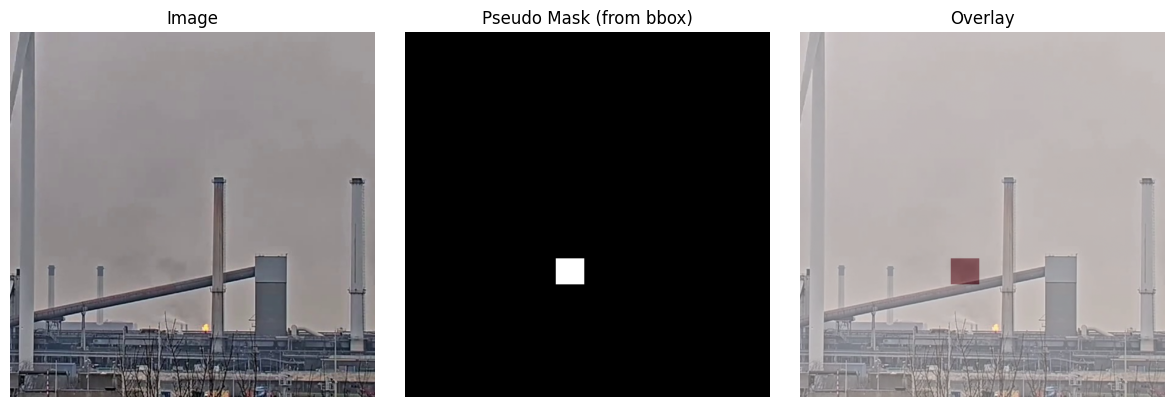

In [5]:
# Custom Dataset for IJmond Bbox Data
class IJmondBboxDataset(Dataset):
    """
    Loads .npy images and creates pseudo masks from bounding box annotations.
    
    For GuidedBox, we need:
    - images: RGB input images
    - boxes: bounding box coordinates [x, y, w, h] normalized to [0, 1]
    - masks: pseudo binary masks generated from bounding boxes
    """
    def __init__(self, records, img_npy_dir, img_size=256):
        self.records = records
        self.img_npy_dir = img_npy_dir
        self.img_size = img_size
        
    def __len__(self):
        return len(self.records)
    
    def __getitem__(self, idx):
        record = self.records[idx]
        
        # Load image from .npy file
        img_path = os.path.join(self.img_npy_dir, f"{record['id']}.npy")
        image = np.load(img_path)  # (H, W, 3) uint8
        
        # Get original image dimensions and bbox
        h_img, w_img = record['h_image'], record['w_image']
        x_bbox, y_bbox = record['x_bbox'], record['y_bbox']
        w_bbox, h_bbox = record['w_bbox'], record['h_bbox']
        
        # The npy image might be a different size than h_image/w_image
        # (npy is 600x600 or 900x900, bbox coords are relative to h_image/w_image)
        actual_h, actual_w = image.shape[:2]
        scale_x = actual_w / w_img
        scale_y = actual_h / h_img
        
        # Scale bbox to actual image coordinates
        x_bbox_scaled = int(x_bbox * scale_x)
        y_bbox_scaled = int(y_bbox * scale_y)
        w_bbox_scaled = int(w_bbox * scale_x)
        h_bbox_scaled = int(h_bbox * scale_y)
        
        # Create pseudo mask from bounding box (binary: 1 inside box, 0 outside)
        pseudo_mask = np.zeros((actual_h, actual_w), dtype=np.float32)
        x1 = max(0, x_bbox_scaled)
        y1 = max(0, y_bbox_scaled)
        x2 = min(actual_w, x_bbox_scaled + w_bbox_scaled)
        y2 = min(actual_h, y_bbox_scaled + h_bbox_scaled)
        pseudo_mask[y1:y2, x1:x2] = 1.0
        
        # Resize image and mask
        image_pil = Image.fromarray(image).resize((self.img_size, self.img_size), Image.BILINEAR)
        mask_pil = Image.fromarray((pseudo_mask * 255).astype(np.uint8)).resize(
            (self.img_size, self.img_size), Image.NEAREST
        )
        
        # Convert to tensors
        image_tensor = TF.to_tensor(image_pil)  # [3, H, W], [0, 1]
        mask_tensor = torch.from_numpy(np.array(mask_pil)).float() / 255.0
        mask_tensor = mask_tensor.unsqueeze(0)  # [1, H, W]
        
        # Normalize image (ImageNet stats for ResNet50 backbone)
        image_tensor = TF.normalize(image_tensor, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        
        # Normalized bbox [x, y, w, h] in [0, 1] range (relative to resized image)
        box_tensor = torch.tensor([
            x_bbox / w_img,
            y_bbox / h_img,
            w_bbox / w_img,
            h_bbox / h_img
        ], dtype=torch.float32)
        
        return image_tensor, box_tensor, mask_tensor

# Test the dataset
test_ds = IJmondBboxDataset(train_records[:5], config['img_npy_path'], img_size=config['img_size'])
sample_img, sample_box, sample_mask = test_ds[2]
print(f"Image shape: {sample_img.shape}, Box: {sample_box}, Mask shape: {sample_mask.shape}")
print(f"Mask sum (pixels in box): {sample_mask.sum().item():.0f} / {sample_mask.numel()}")

# Visualize a sample
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
# Denormalize image
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
img_display = (sample_img * std + mean).permute(1, 2, 0).numpy().clip(0, 1)

axes[0].imshow(img_display)
axes[0].set_title("Image")
axes[0].axis('off')

axes[1].imshow(sample_mask[0], cmap='gray')
axes[1].set_title("Pseudo Mask (from bbox)")
axes[1].axis('off')

axes[2].imshow(img_display)
axes[2].imshow(sample_mask[0], alpha=0.4, cmap='Reds')
axes[2].set_title("Overlay")
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [6]:
# Create Data Loaders
IMG_SIZE = config['img_size']
BATCH_SIZE = config['batch_size']
VAL_SPLIT = 0.2

# Create full dataset
full_dataset = IJmondBboxDataset(train_records, config['img_npy_path'], img_size=IMG_SIZE)

# Split into train and validation
val_size = int(len(full_dataset) * VAL_SPLIT)
train_size = len(full_dataset) - val_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Batches per epoch: {len(train_loader)}")

# Verify a batch
images, boxes, masks = next(iter(train_loader))
print(f"\nBatch shapes:")
print(f"  Images: {images.shape}")
print(f"  Boxes: {boxes.shape}")
print(f"  Masks: {masks.shape}")

Training samples: 488
Validation samples: 122
Batches per epoch: 16

Batch shapes:
  Images: torch.Size([32, 3, 1024, 1024])
  Boxes: torch.Size([32, 4])
  Masks: torch.Size([32, 1, 1024, 1024])


In [7]:
# GuidedBox Model - Original Architecture by Teerapong Panboonyuen
# Adapted for binary smoke segmentation from bounding box supervision
#
# NOTE: The original code uses `self.backbone = models.resnet50(pretrained=True)`
# but ResNet50's default forward() returns [B, 1000] (classification output).
# The teacher/student Conv2d layers need 4D feature maps [B, 2048, H, W].
# So we extract only the convolutional layers (removing avgpool + fc).

class GuidedBoxModel(nn.Module):
    def __init__(self, config):
        super(GuidedBoxModel, self).__init__()
        
        # Load ResNet50 and extract only convolutional feature layers
        resnet = models.resnet101(pretrained=True)
        self.backbone = nn.Sequential(
            resnet.conv1,
            resnet.bn1,
            resnet.relu,
            resnet.maxpool,
            resnet.layer1,  # [B, 256, H/4, W/4]
            resnet.layer2,  # [B, 512, H/8, W/8]
            resnet.layer3,  # [B, 1024, H/16, W/16]
            resnet.layer4,  # [B, 2048, H/32, W/32]
        )
        
        self.teacher = nn.Sequential(
            nn.Conv2d(2048, 1024, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(1024, 512, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, config['num_classes'], kernel_size=1)
        )
        self.student = nn.Sequential(
            nn.Conv2d(2048, 1024, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(1024, 512, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, config['num_classes'], kernel_size=1)
        )
        self.alpha = config['ema_alpha']

    def forward(self, images, positive_weight, boxes=None, masks=None):
        features = self.backbone(images)       # [B, 2048, H/32, W/32]
        teacher_output = self.teacher(features)  # [B, num_classes, H/32, W/32]
        student_output = self.student(features)  # [B, num_classes, H/32, W/32]
        
        # Upsample predictions to original image size
        teacher_output = F.interpolate(teacher_output, size=images.shape[2:], mode='bilinear', align_corners=False)
        student_output = F.interpolate(student_output, size=images.shape[2:], mode='bilinear', align_corners=False)
        
        if self.training:
            loss = self.compute_loss(teacher_output, student_output, boxes=boxes, masks=masks, positive_weight=positive_weight)
            return loss
        else:
            return student_output

    def compute_loss(self, teacher_output, student_output, boxes, masks, positive_weight):
        """
        Compute combined loss for training.
        - box_loss: MSE between teacher and student (consistency regularization)
        - mask_loss: robust pseudo mask loss with confidence weighting
        """
        conf_scores = self.compute_confidence_scores(teacher_output, student_output)
        mask_loss = self.robust_pseudo_mask_loss(student_output, masks, conf_scores, positive_weight=positive_weight)
        box_loss = F.mse_loss(teacher_output, student_output)
        return box_loss + mask_loss

    
    def robust_pseudo_mask_loss(self, preds, pseudo_masks, conf_scores, positive_weight=5):
        """Compute robust pseudo mask loss with confidence weighting."""
        pixel_loss = F.binary_cross_entropy_with_logits(
            preds, pseudo_masks, 
            pos_weight=torch.tensor(positive_weight)
        )
        affinity_loss = self.enhanced_mask_affinity_loss(preds, pseudo_masks)
        return torch.mean(conf_scores * (0.4 * pixel_loss + 0.1 * affinity_loss))
    
    def enhanced_mask_affinity_loss(self, preds, pseudo_masks):
        """Compute enhanced mask affinity loss using local context."""
        eps = 1e-7
        affinity_loss = 0.0
        for i in range(preds.size(0)):
            mask_pred = torch.sigmoid(preds[i])
            mask_pred = torch.clamp(mask_pred, eps, 1 - eps)
            
            neighbors = F.max_pool2d(
                mask_pred.unsqueeze(0), kernel_size=3, stride=1, padding=1
            ).squeeze(0) > 0.45
            
            fg_loss = 0.0
            bg_loss = 0.0
            if neighbors.sum() > 0:
                fg_loss = -torch.mean(torch.log(mask_pred[neighbors]))
            if (~neighbors).sum() > 0:
                bg_loss = -torch.mean(torch.log(1 - mask_pred[~neighbors]))
            
            affinity_loss += fg_loss + bg_loss
        return affinity_loss / preds.size(0)

    def compute_confidence_scores(self, teacher_output, student_output):
        """Compute confidence scores via cosine similarity."""
        return torch.sigmoid(F.cosine_similarity(teacher_output, student_output))
    
    def update_teacher(self):
        """Update teacher network parameters using EMA."""
        for t_param, s_param in zip(self.teacher.parameters(), self.student.parameters()):
            t_param.data = self.alpha * t_param.data + (1 - self.alpha) * s_param.data

# Count parameters
model = GuidedBoxModel(config)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

c:\Users\lydia\coding\image_seg\img_venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\lydia\coding\image_seg\img_venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Total parameters: 89,690,178
Trainable parameters: 89,690,178


In [8]:
# Initialize model and move to device
model = GuidedBoxModel(config)
model = model.to(config['device'])

# Freeze backbone for first few epochs (optional, speeds up training)
# for param in model.backbone.parameters():
#     param.requires_grad = False

print(f"Model on device: {config['device']}")
print(f"Backbone frozen: False")

Model on device: cpu
Backbone frozen: False


In [9]:
# Helper functions for metrics
def calculate_iou(pred, target, threshold=0.5):
    """Calculate Intersection over Union"""
    pred_binary = (torch.sigmoid(pred) > threshold).float()
    intersection = (pred_binary * target).sum()
    union = pred_binary.sum() + target.sum() - intersection
    return (intersection / (union + 1e-8)).item()

def calculate_dice(pred, target, threshold=0.5):
    """Calculate Dice coefficient"""
    pred_binary = (torch.sigmoid(pred) > threshold).float()
    intersection = (pred_binary * target).sum()
    return (2 * intersection / (pred_binary.sum() + target.sum() + 1e-8)).item()

# Lists for tracking metrics
train_losses = []
val_losses = []
val_ious = []

print("Metrics functions ready.")

Metrics functions ready.


In [ ]:
# Training Loop
NUM_EPOCHS = config['num_epochs']
LEARNING_RATE = config['learning_rate']
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(f"Training for {NUM_EPOCHS} epochs, lr={LEARNING_RATE}")
print(f"Dataset: {len(train_dataset)} train, {len(val_dataset)} val samples")
print("-" * 60)

for epoch in range(NUM_EPOCHS):
    # --- Training phase ---
    model.train()
    epoch_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
    
    for images, boxes, masks in pbar:
        images = images.to(config['device'])
        boxes = boxes.to(config['device'])
        masks = masks.to(config['device'])
        
        # Forward pass - model returns loss during training
        loss = model(images, boxes=boxes, masks=masks, positive_weight=config['positive_weight'])
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Update teacher network with EMA
        model.update_teacher()
        
        epoch_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # --- Validation phase ---
    model.eval()
    epoch_val_loss = 0.0
    epoch_iou = 0.0
    
    with torch.no_grad():
        for images, boxes, masks in val_loader:
            images = images.to(config['device'])
            boxes = boxes.to(config['device'])
            masks = masks.to(config['device'])
            
            # Get predictions (model returns student output in eval mode)
            outputs = model(images, positive_weight=config['positive_weight'])
            
            # Compute validation loss manually
            val_loss = F.binary_cross_entropy_with_logits(outputs, masks)
            epoch_val_loss += val_loss.item()
            epoch_iou += calculate_iou(outputs, masks)
    
    avg_val_loss = epoch_val_loss / len(val_loader)
    avg_iou = epoch_iou / len(val_loader)
    val_losses.append(avg_val_loss)
    val_ious.append(avg_iou)
    
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}: Train Loss={avg_train_loss:.4f}, Val Loss={avg_val_loss:.4f}, IoU={avg_iou:.4f}")

print("\n" + "=" * 60)
print("Training complete!")

# Save the trained model
os.makedirs(config['save_path'], exist_ok=True)
save_file = os.path.join(config['save_path'], 'guidedbox_model.pth')
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_losses': train_losses,
    'val_losses': val_losses,
    'val_ious': val_ious,
    'epoch': NUM_EPOCHS,
    'config': config,
}, save_file)
print(f"Model saved to: {save_file}")

Training for 10 epochs, lr=0.0001
Dataset: 488 train, 122 val samples
------------------------------------------------------------


Epoch 1/10:   0%|          | 0/16 [00:00<?, ?it/s]

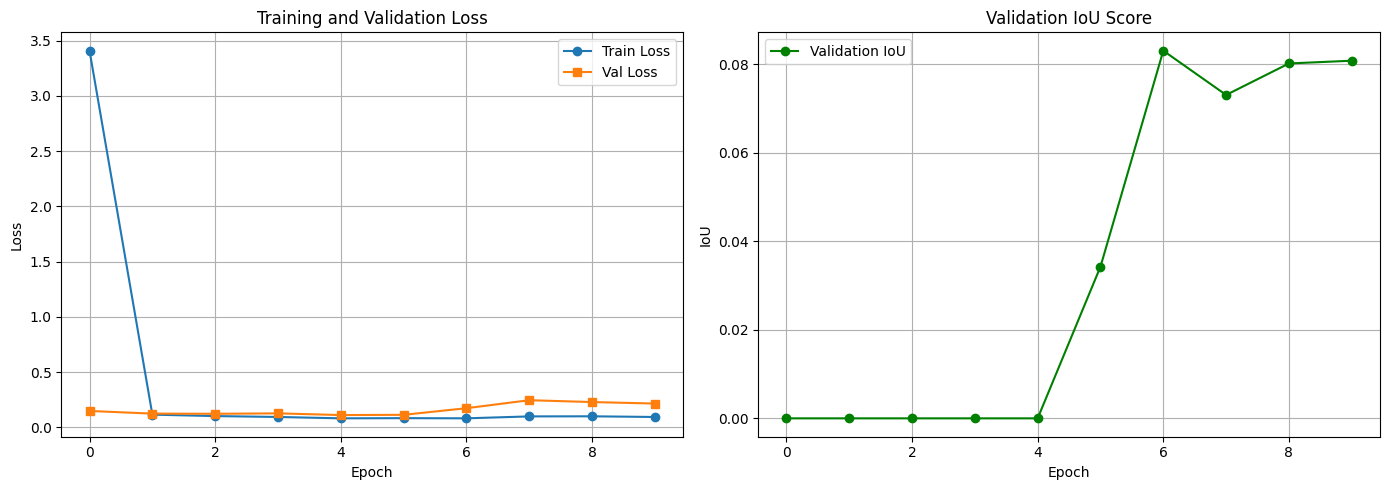

Best Validation IoU: 0.0831 at epoch 7


In [ ]:
# Plot Training History
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(train_losses, label='Train Loss', marker='o')
axes[0].plot(val_losses, label='Val Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# IoU plot
axes[1].plot(val_ious, label='Validation IoU', marker='o', color='green')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('IoU')
axes[1].set_title('Validation IoU Score')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

if val_ious:
    print(f"Best Validation IoU: {max(val_ious):.4f} at epoch {val_ious.index(max(val_ious)) + 1}")

In [ ]:
# Visualize Predictions on Validation Set
def visualize_predictions(model, dataloader, num_samples=4):
    """Display sample predictions vs pseudo mask ground truth"""
    model.eval()
    
    # Get a batch
    images, boxes, masks = next(iter(dataloader))
    images = images.to(config['device'])
    
    with torch.no_grad():
        predictions = model(images)
        predictions = torch.sigmoid(predictions)  # Convert logits to probabilities
    
    # Move to CPU for plotting
    images = images.cpu()
    masks = masks.cpu()
    boxes = boxes.cpu()
    predictions = predictions.cpu()
    
    # Denormalize images
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    
    num_samples = min(num_samples, len(images))
    fig, axes = plt.subplots(num_samples, 4, figsize=(16, 5 * num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    for i in range(num_samples):
        img = images[i] * std + mean
        img = img.permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)
        
        gt_mask = masks[i, 0].numpy()
        pred_mask = predictions[i, 0].numpy()
        pred_binary = (pred_mask > 0.5).astype(float)
        
        axes[i, 0].imshow(img)
        axes[i, 0].set_title("Input Image")
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(gt_mask, cmap='gray')
        axes[i, 1].set_title("Pseudo Mask (bbox)")
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(pred_mask, cmap='hot')
        axes[i, 2].set_title("Prediction (Prob)")
        axes[i, 2].axis('off')
        
        axes[i, 3].imshow(img)
        axes[i, 3].imshow(pred_binary, alpha=0.5, cmap='Reds')
        axes[i, 3].set_title("Overlay")
        axes[i, 3].axis('off')
    
    plt.suptitle("GuidedBox Predictions on IJmond Validation Set", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

visualize_predictions(model, val_loader, num_samples=8)

NameError: name 'model' is not defined

In [ ]:
# Final Evaluation on Validation Set
model.eval()
total_iou = 0
total_dice = 0
num_batches = 0

with torch.no_grad():
    for images, boxes, masks in val_loader:
        images = images.to(config['device'])
        masks = masks.to(config['device'])
        
        outputs = model(images, config['positive_weight'])
        
        total_iou += calculate_iou(outputs, masks)
        total_dice += calculate_dice(outputs, masks)
        num_batches += 1

final_iou = total_iou / num_batches
final_dice = total_dice / num_batches

print("=" * 50)
print("Final Evaluation on Validation Set")
print("=" * 50)
print(f"IoU (Intersection over Union): {final_iou:.4f}")
print(f"Dice Coefficient: {final_dice:.4f}")
print("=" * 50)

Final Evaluation on Validation Set
IoU (Intersection over Union): 0.0000
Dice Coefficient: 0.0000


# Grid Search: Hyperparameter Tuning

Search over combinations of **learning rate**, **EMA alpha**, and **image size** to find the best performing model. Each combination is trained, evaluated, and saved.

In [ ]:
# Define Grid Search Parameter Combinations
from itertools import product
import time

# Parameter grid
param_grid = {
    'learning_rate': [0.0001, 0.0002, 0.0005],
    'ema_alpha': [0.85, 0.9, 0.95],
    'img_size': [512, 1024],
    'positive_weight': [1.5, 2, 2.5, 3]
}

# Generate all combinations
keys = list(param_grid.keys())
values = list(param_grid.values())
all_combinations = [dict(zip(keys, combo)) for combo in product(*values)]

print(f"Total combinations to search: {len(all_combinations)}")
print(f"Fixed params: batch_size={config['batch_size']}, num_epochs=10, device={config['device']}")
print(f"\nCombinations:")
for i, combo in enumerate(all_combinations):
    print(f"  [{i+1}] lr={combo['learning_rate']}, ema_alpha={combo['ema_alpha']}, img_size={combo['img_size']}, positive_weight={combo['positive_weight']}")

Total combinations to search: 72
Fixed params: batch_size=8, num_epochs=10, device=cpu

Combinations:
  [1] lr=0.0001, ema_alpha=0.85, img_size=128, positive_weight=3
  [2] lr=0.0001, ema_alpha=0.85, img_size=128, positive_weight=5
  [3] lr=0.0001, ema_alpha=0.85, img_size=128, positive_weight=7
  [4] lr=0.0001, ema_alpha=0.85, img_size=128, positive_weight=9
  [5] lr=0.0001, ema_alpha=0.85, img_size=256, positive_weight=3
  [6] lr=0.0001, ema_alpha=0.85, img_size=256, positive_weight=5
  [7] lr=0.0001, ema_alpha=0.85, img_size=256, positive_weight=7
  [8] lr=0.0001, ema_alpha=0.85, img_size=256, positive_weight=9
  [9] lr=0.0001, ema_alpha=0.9, img_size=128, positive_weight=3
  [10] lr=0.0001, ema_alpha=0.9, img_size=128, positive_weight=5
  [11] lr=0.0001, ema_alpha=0.9, img_size=128, positive_weight=7
  [12] lr=0.0001, ema_alpha=0.9, img_size=128, positive_weight=9
  [13] lr=0.0001, ema_alpha=0.9, img_size=256, positive_weight=3
  [14] lr=0.0001, ema_alpha=0.9, img_size=256, positiv

In [ ]:
len(train_records)

610

In [ ]:
save_train_records = train_records.copy()
train_records = train_records[:20]

In [ ]:
# Grid Search Training Loop
GRID_EPOCHS = 10  # Epochs per combination (keep low for speed)
GRID_SAVE_DIR = 'guided_box_ijmond/grid_search'
os.makedirs(GRID_SAVE_DIR, exist_ok=True)

# Store results for all combinations
grid_results = []

for run_idx, params in enumerate(all_combinations):
    run_name = f"lr{params['learning_rate']}_ema{params['ema_alpha']}_img{params['img_size']}_positive_weight{params['positive_weight']}"
    print(f"\n{'='*70}")
    print(f"[{run_idx+1}/{len(all_combinations)}] {run_name}")
    print(f"{'='*70}")
    
    start_time = time.time()
    
    # --- Rebuild dataset and loaders with this img_size ---
    run_dataset = IJmondBboxDataset(train_records, config['img_npy_path'], img_size=params['img_size'])
    run_val_size = int(len(run_dataset) * 0.2)
    run_train_size = len(run_dataset) - run_val_size
    run_train_ds, run_val_ds = random_split(run_dataset, [run_train_size, run_val_size],
                                             generator=torch.Generator().manual_seed(42))
    run_train_loader = DataLoader(run_train_ds, batch_size=config['batch_size'], shuffle=True, num_workers=0)
    run_val_loader = DataLoader(run_val_ds, batch_size=config['batch_size'], shuffle=False, num_workers=0)
    
    # --- Build model with this ema_alpha ---
    run_config = config.copy()
    run_config['ema_alpha'] = params['ema_alpha']
    run_model = GuidedBoxModel(run_config).to(config['device'])
    run_optimizer = torch.optim.Adam(run_model.parameters(), lr=params['learning_rate'])
    
    # --- Training ---
    run_train_losses = []
    run_val_losses = []
    run_val_ious = []
    best_iou = 0.0
    
    for epoch in range(GRID_EPOCHS):
        # Training
        run_model.train()
        epoch_loss = 0.0
        for images, boxes, masks in run_train_loader:
            images = images.to(config['device'])
            boxes = boxes.to(config['device'])
            masks = masks.to(config['device'])
            
            loss = run_model(images, boxes=boxes, masks=masks, positive_weight=params['positive_weight'])
            run_optimizer.zero_grad()
            loss.backward()
            run_optimizer.step()
            run_model.update_teacher()
            epoch_loss += loss.item()
        
        avg_train_loss = epoch_loss / len(run_train_loader)
        run_train_losses.append(avg_train_loss)
        
        # Validation
        run_model.eval()
        epoch_val_loss = 0.0
        epoch_iou = 0.0
        with torch.no_grad():
            for images, boxes, masks in run_val_loader:
                images = images.to(config['device'])
                masks = masks.to(config['device'])
                outputs = run_model(images, params['positive_weight'])
                val_loss = F.binary_cross_entropy_with_logits(outputs, masks, pos_weight=torch.tensor(params['positive_weight']).to(config['device']))
                epoch_val_loss += val_loss.item()
                epoch_iou += calculate_iou(outputs, masks)
        
        avg_val_loss = epoch_val_loss / len(run_val_loader)
        avg_iou = epoch_iou / len(run_val_loader)
        run_val_losses.append(avg_val_loss)
        run_val_ious.append(avg_iou)
        
        if avg_iou > best_iou:
            best_iou = avg_iou
        
        print(f"  Epoch {epoch+1}/{GRID_EPOCHS}: Train={avg_train_loss:.4f}, Val={avg_val_loss:.4f}, IoU={avg_iou:.4f}")
    
    elapsed = time.time() - start_time
    
    # --- Save model ---
    save_path = os.path.join(GRID_SAVE_DIR, f'{run_name}.pth')
    torch.save({
        'model_state_dict': run_model.state_dict(),
        'params': params,
        'train_losses': run_train_losses,
        'val_losses': run_val_losses,
        'val_ious': run_val_ious,
        'best_iou': best_iou,
        'final_iou': run_val_ious[-1],
        'final_val_loss': run_val_losses[-1],
    }, save_path)
    
    # Store result
    grid_results.append({
        'run_name': run_name,
        'learning_rate': params['learning_rate'],
        'ema_alpha': params['ema_alpha'],
        'img_size': params['img_size'],
        'best_iou': best_iou,
        'final_iou': run_val_ious[-1],
        'final_val_loss': run_val_losses[-1],
        'final_train_loss': run_train_losses[-1],
        'train_losses': run_train_losses,
        'val_losses': run_val_losses,
        'val_ious': run_val_ious,
        'time_seconds': elapsed,
        'save_path': save_path,
    })
    
    print(f"  Best IoU: {best_iou:.4f} | Time: {elapsed:.1f}s | Saved: {save_path}")

print(f"\n{'='*70}")
print(f"Grid search complete! {len(grid_results)} models trained and saved.")
print(f"{'='*70}")


[1/72] lr0.0001_ema0.85_img128_positive_weight3
  Epoch 1/10: Train=5.3826, Val=0.6566, IoU=0.0000
  Epoch 1/10: Train=5.3826, Val=0.6566, IoU=0.0000
  Epoch 2/10: Train=0.2173, Val=0.8106, IoU=0.0553
  Epoch 2/10: Train=0.2173, Val=0.8106, IoU=0.0553
  Epoch 3/10: Train=0.1245, Val=0.7842, IoU=0.0432
  Epoch 3/10: Train=0.1245, Val=0.7842, IoU=0.0432
  Epoch 4/10: Train=0.1547, Val=0.7520, IoU=0.0000
  Epoch 4/10: Train=0.1547, Val=0.7520, IoU=0.0000
  Epoch 5/10: Train=0.1135, Val=0.7613, IoU=0.0000
  Epoch 5/10: Train=0.1135, Val=0.7613, IoU=0.0000
  Epoch 6/10: Train=0.2457, Val=0.7665, IoU=0.0591
  Epoch 6/10: Train=0.2457, Val=0.7665, IoU=0.0591
  Epoch 7/10: Train=0.2623, Val=0.7509, IoU=0.0000
  Epoch 7/10: Train=0.2623, Val=0.7509, IoU=0.0000
  Epoch 8/10: Train=0.2761, Val=0.7361, IoU=0.0000
  Epoch 8/10: Train=0.2761, Val=0.7361, IoU=0.0000
  Epoch 9/10: Train=0.2740, Val=0.7293, IoU=0.0000
  Epoch 9/10: Train=0.2740, Val=0.7293, IoU=0.0000
  Epoch 10/10: Train=0.2897, Val=

KeyboardInterrupt: 

In [ ]:
# Results Summary Table
import pandas as pd

results_df = pd.DataFrame([{
    'Run': r['run_name'],
    'LR': r['learning_rate'],
    'EMA Alpha': r['ema_alpha'],
    'Img Size': r['img_size'],
    'Best IoU': r['best_iou'],
    'Final IoU': r['final_iou'],
    'Final Val Loss': r['final_val_loss'],
    'Final Train Loss': r['final_train_loss'],
    'Time (s)': round(r['time_seconds'], 1),
} for r in grid_results])

# Sort by Best IoU descending
results_df = results_df.sort_values('Best IoU', ascending=False).reset_index(drop=True)
results_df.index += 1  # 1-based ranking
results_df.index.name = 'Rank'

print("=" * 80)
print("GRID SEARCH RESULTS (sorted by Best IoU)")
print("=" * 80)
display(results_df)

# Identify best model
best_result = grid_results[0]
for r in grid_results:
    if r['best_iou'] > best_result['best_iou']:
        best_result = r

print(f"\n🏆 BEST MODEL: {best_result['run_name']}")
print(f"   Best IoU: {best_result['best_iou']:.4f}")
print(f"   LR: {best_result['learning_rate']}, EMA: {best_result['ema_alpha']}, Img Size: {best_result['img_size']}")
print(f"   Saved at: {best_result['save_path']}")

In [ ]:
# Plot Grid Search Results Comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. IoU curves for all runs
ax = axes[0, 0]
for r in grid_results:
    ax.plot(range(1, len(r['val_ious'])+1), r['val_ious'], label=r['run_name'], alpha=0.7)
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation IoU')
ax.set_title('Validation IoU Across All Runs')
ax.legend(fontsize=6, ncol=2, loc='lower right')
ax.grid(True)

# 2. Val loss curves for all runs
ax = axes[0, 1]
for r in grid_results:
    ax.plot(range(1, len(r['val_losses'])+1), r['val_losses'], label=r['run_name'], alpha=0.7)
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Loss')
ax.set_title('Validation Loss Across All Runs')
ax.legend(fontsize=6, ncol=2, loc='upper right')
ax.grid(True)

# 3. Best IoU bar chart by learning rate
ax = axes[1, 0]
lr_groups = {}
for r in grid_results:
    lr = r['learning_rate']
    if lr not in lr_groups:
        lr_groups[lr] = []
    lr_groups[lr].append(r['best_iou'])
lr_labels = [str(lr) for lr in sorted(lr_groups.keys())]
lr_means = [np.mean(lr_groups[float(lr)]) for lr in lr_labels]
lr_maxs = [np.max(lr_groups[float(lr)]) for lr in lr_labels]
x = range(len(lr_labels))
ax.bar([i - 0.15 for i in x], lr_means, 0.3, label='Mean IoU', color='steelblue')
ax.bar([i + 0.15 for i in x], lr_maxs, 0.3, label='Max IoU', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(lr_labels)
ax.set_xlabel('Learning Rate')
ax.set_ylabel('IoU')
ax.set_title('Best IoU by Learning Rate')
ax.legend()
ax.grid(axis='y')

# 4. Best IoU bar chart by EMA alpha
ax = axes[1, 1]
ema_groups = {}
for r in grid_results:
    ema = r['ema_alpha']
    if ema not in ema_groups:
        ema_groups[ema] = []
    ema_groups[ema].append(r['best_iou'])
ema_labels = [str(e) for e in sorted(ema_groups.keys())]
ema_means = [np.mean(ema_groups[float(e)]) for e in ema_labels]
ema_maxs = [np.max(ema_groups[float(e)]) for e in ema_labels]
x = range(len(ema_labels))
ax.bar([i - 0.15 for i in x], ema_means, 0.3, label='Mean IoU', color='steelblue')
ax.bar([i + 0.15 for i in x], ema_maxs, 0.3, label='Max IoU', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(ema_labels)
ax.set_xlabel('EMA Alpha')
ax.set_ylabel('IoU')
ax.set_title('Best IoU by EMA Alpha')
ax.legend()
ax.grid(axis='y')

plt.suptitle('Grid Search Results Overview', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Load Best Model and Visualize Predictions
print(f"Loading best model: {best_result['run_name']}")
print(f"  Best IoU: {best_result['best_iou']:.4f}")
print(f"  Params: LR={best_result['learning_rate']}, EMA={best_result['ema_alpha']}, Img={best_result['img_size']}")

# Rebuild config for best model
best_config = config.copy()
best_config['ema_alpha'] = best_result['ema_alpha']

# Load model
best_model = GuidedBoxModel(best_config).to(config['device'])
checkpoint = torch.load(best_result['save_path'], weights_only=False)
best_model.load_state_dict(checkpoint['model_state_dict'])
best_model.eval()

# Rebuild dataloader with best img_size
best_dataset = IJmondBboxDataset(train_records, config['img_npy_path'], img_size=best_result['img_size'])
best_val_size = int(len(best_dataset) * 0.2)
best_train_size = len(best_dataset) - best_val_size
_, best_val_ds = random_split(best_dataset, [best_train_size, best_val_size],
                               generator=torch.Generator().manual_seed(42))
best_val_loader = DataLoader(best_val_ds, batch_size=config['batch_size'], shuffle=False, num_workers=0)

# Evaluate
total_iou = 0
total_dice = 0
num_batches = 0
with torch.no_grad():
    for images, boxes, masks in best_val_loader:
        images = images.to(config['device'])
        masks = masks.to(config['device'])
        outputs = best_model(images)
        total_iou += calculate_iou(outputs, masks)
        total_dice += calculate_dice(outputs, masks)
        num_batches += 1

print(f"\n{'='*50}")
print(f"Best Model Final Evaluation")
print(f"{'='*50}")
print(f"IoU:  {total_iou / num_batches:.4f}")
print(f"Dice: {total_dice / num_batches:.4f}")
print(f"{'='*50}")

# Visualize predictions
images, boxes, masks = next(iter(best_val_loader))
images = images.to(config['device'])

with torch.no_grad():
    predictions = torch.sigmoid(best_model(images)).cpu()

images = images.cpu()
masks = masks.cpu()

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

num_show = min(6, len(images))
fig, axes = plt.subplots(num_show, 4, figsize=(16, 4 * num_show))
if num_show == 1:
    axes = axes.reshape(1, -1)

for i in range(num_show):
    img = (images[i] * std + mean).permute(1, 2, 0).numpy().clip(0, 1)
    gt_mask = masks[i, 0].numpy()
    pred_mask = predictions[i, 0].numpy()
    pred_binary = (pred_mask > 0.5).astype(float)
    
    axes[i, 0].imshow(img)
    axes[i, 0].set_title("Input Image")
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(gt_mask, cmap='gray')
    axes[i, 1].set_title("Pseudo Mask (bbox)")
    axes[i, 1].axis('off')
    
    axes[i, 2].imshow(pred_mask, cmap='hot')
    axes[i, 2].set_title("Prediction (Prob)")
    axes[i, 2].axis('off')
    
    axes[i, 3].imshow(img)
    axes[i, 3].imshow(pred_binary, alpha=0.5, cmap='Reds')
    axes[i, 3].set_title("Overlay")
    axes[i, 3].axis('off')

plt.suptitle(f"Best Model: {best_result['run_name']} (IoU={best_result['best_iou']:.4f})", 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()